# R07 Final Model — Performance & SHAP Analysis

**Model**: R07 (`S2_Reduced`) — LightGBM multiclass signal detector  
**Target**: 5-day excess return of TD vs XFN sector ETF (`target_excess_xfn_5d`)  
**Labels**: Outperform (+1) / Neutral (0) / Underperform (−1), band ±0.30%  
**Features**: 30 curated event-style + market/macro features  
**Validation**: 7-fold expanding-window walk-forward (stride-5 offset averaging)

This notebook:
1. Loads the locked R07 artifact and verifies it
2. Re-runs the 7-fold walk-forward evaluation
3. Reports per-fold and aggregate performance (DirAcc, active sign accuracy, coverage)
4. Generates SHAP analysis (global importance + fold heatmap)

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import shap

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path('').resolve()
ROOT = NOTEBOOK_DIR.parents[1]          # project root
EXP_PARENT = ROOT / 'step3_predictive_model/model_experiments'

for p in [str(ROOT), str(EXP_PARENT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

ARTIFACT_DIR = NOTEBOOK_DIR / 'artifacts'

print(f'ROOT: {ROOT}')
print(f'Artifact dir: {ARTIFACT_DIR}')

ROOT: /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis
Artifact dir: /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis/step3_predictive_model/final_model/artifacts


## 1. Load & Verify Artifact

In [2]:
import pickle, json

pkl_files = sorted(ARTIFACT_DIR.glob('r07-current-best-*.pkl'))
assert pkl_files, 'No R07 artifact found in artifacts/'
pkl_path = pkl_files[-1]   # most recent
json_path = pkl_path.with_suffix('.json')

with open(pkl_path, 'rb') as f:
    artifact = pickle.load(f)

with open(json_path) as f:
    meta = json.load(f)

model     = artifact['model']
features  = artifact['features']
TARGET    = artifact['target']
THRESHOLD = artifact['threshold']
label_map = artifact['label_map']       # {-1:0, 0:1, 1:2}
inv_map   = artifact['inverse_label_map']

assert meta['features'] == features, 'Feature mismatch between pkl and json!'

print(f'Artifact : {pkl_path.name}')
print(f'Target   : {TARGET}')
print(f'Threshold: ±{THRESHOLD*100:.1f}%')
print(f'Features : {len(features)}')
print(f'Model    : {model}')

Artifact : r07-current-best-2026-04-21.pkl
Target   : target_excess_xfn_5d
Threshold: ±0.3%
Features : 30
Model    : LGBMClassifier(feature_fraction=0.8, learning_rate=0.05, min_child_samples=40,
               n_estimators=120, n_jobs=1, num_class=3, num_leaves=8,
               objective='multiclass', random_state=42, reg_alpha=0.2,
               reg_lambda=1.0, verbose=-1)


## 2. Load Dataset

In [3]:
from redesign_single_stock.src.run_redesign_experiments import load_dataset, label_3class
from src.models.walk_forward_config import E10_FOLDS, STRIDE_EVAL

df = load_dataset()
print(f'Dataset: {len(df)} rows, {df["date"].min().date()} – {df["date"].max().date()}')
print(f'Missing features: {[f for f in features if f not in df.columns]}')

Dataset: 1285 rows, 2021-02-25 – 2026-04-09
Missing features: []


## 3. Walk-Forward Evaluation

In [4]:
import lightgbm as lgb
from sklearn.metrics import f1_score

STRIDE  = STRIDE_EVAL
OFFSETS = list(range(STRIDE))


def fit_predict(train_df, test_df):
    x_tr = train_df[features].fillna(train_df[features].median())
    y_tr = label_3class(train_df[TARGET].values, threshold=THRESHOLD)
    y_enc = np.array([label_map[v] for v in y_tr], dtype=int)

    clf = lgb.LGBMClassifier(
        objective='multiclass', num_class=3,
        n_estimators=120, learning_rate=0.05, num_leaves=8,
        min_child_samples=40, feature_fraction=0.8,
        reg_alpha=0.2, reg_lambda=1.0,
        random_state=42, verbose=-1, n_jobs=1,
    )
    clf.fit(x_tr, y_enc)

    x_te      = test_df[features].fillna(train_df[features].median())
    y_te_cls  = label_3class(test_df[TARGET].values, threshold=THRESHOLD)
    y_te_cont = test_df[TARGET].values           # raw continuous excess return
    preds_enc = clf.predict(x_te)
    preds = np.array([inv_map[p] for p in preds_enc])
    return clf, preds, y_te_cls, y_te_cont


def offset_metrics(preds, y_true_cls, y_true_cont, dates):
    """
    active_asa uses the CONTINUOUS excess return for sign comparison (matching
    run_redesign_experiments.py). This means even a neutral-labeled return that
    moves in the predicted direction counts as directionally correct — the right
    behaviour for a signal-detector framing.
    """
    rows = []
    for off in OFFSETS:
        idx = np.arange(off, len(dates), STRIDE)
        p, y_cls, y_cont = preds[idx], y_true_cls[idx], y_true_cont[idx]
        active = (p != 0)
        valid_active = active.sum() > 0
        rows.append({
            'mean_acc': (p == y_cls).mean(),
            'macro_f1': f1_score(y_cls, p, average='macro', zero_division=0, labels=[-1, 0, 1]),
            'active_cov': active.mean(),
            'active_asa': float((np.sign(p[active]) == np.sign(y_cont[active])).mean()) if valid_active else np.nan,
        })
    r = pd.DataFrame(rows).mean()
    return r


fold_results = []
fold_models  = []
fold_shap_dfs = []

# ── Fold date summary ──────────────────────────────────────────────────────────
print("=== Walk-Forward Fold Dates ===")
print(f"{'Fold':<6} {'Train start':<14} {'Train end':<14} {'Test start':<14} {'Test end':<14} {'Test days':>10}")
print("-" * 72)
train_start_global = df[df[TARGET].notna()]['date'].min().date()
for fold_id, train_end, test_start, test_end in E10_FOLDS:
    tr_mask = (df['date'] <= pd.Timestamp(train_end)) & df[TARGET].notna()
    te_mask = (df['date'] >= pd.Timestamp(test_start)) & (df['date'] <= pd.Timestamp(test_end)) & df[TARGET].notna()
    n_test = te_mask.sum()
    print(f"{fold_id:<6} {str(train_start_global):<14} {train_end:<14} {test_start:<14} {test_end:<14} {n_test:>10}")
print("-" * 72)
print(f"  Dataset range : {str(train_start_global)} → {df[df[TARGET].notna()]['date'].max().date()}")
print(f"  Out-of-sample : {E10_FOLDS[0][2]} → {E10_FOLDS[-1][3]}")
print()

for fold_id, train_end, test_start, test_end in E10_FOLDS:
    train_mask = (df['date'] <= pd.Timestamp(train_end)) & df[TARGET].notna()
    test_mask  = (df['date'] >= pd.Timestamp(test_start)) & (df['date'] <= pd.Timestamp(test_end)) & df[TARGET].notna()
    train_df, test_df = df[train_mask], df[test_mask]

    clf, preds, y_true_cls, y_true_cont = fit_predict(train_df, test_df)
    m = offset_metrics(preds, y_true_cls, y_true_cont, test_df['date'].values)

    # SHAP on test set
    explainer  = shap.TreeExplainer(clf)
    x_te_clean = test_df[features].fillna(train_df[features].median())
    shap_vals  = explainer.shap_values(x_te_clean)
    # Handle both old API (list of arrays per class) and new API (3D array)
    if isinstance(shap_vals, list):
        mean_abs = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals], axis=0)
    else:
        sv = np.array(shap_vals)
        if sv.ndim == 3:
            mean_abs = np.abs(sv).mean(axis=(0, 2)) if sv.shape[-1] == 3 else np.abs(sv).mean(axis=(0, 1))
        else:
            mean_abs = np.abs(sv).mean(axis=0)
    shap_ser   = pd.Series(mean_abs, index=features, name=fold_id)
    fold_shap_dfs.append(shap_ser)

    fold_results.append({
        'fold': fold_id, 'train_rows': len(train_df), 'test_rows': len(test_df),
        'train_end': train_end, 'test_start': test_start, 'test_end': test_end,
        **m.to_dict()
    })
    fold_models.append(clf)
    print(f'Fold {fold_id}  mean_acc={m.mean_acc:.3f}  asa={m.active_asa:.3f}  cov={m.active_cov:.3f}')

results_df = pd.DataFrame(fold_results).set_index('fold')
print('\nDone.')

=== Walk-Forward Fold Dates ===
Fold   Train start    Train end      Test start     Test end        Test days
------------------------------------------------------------------------
v1     2021-02-25     2022-12-30     2023-01-10     2023-06-30            121
v2     2021-02-25     2023-06-30     2023-07-11     2023-12-29            119
v3     2021-02-25     2023-12-29     2024-01-09     2024-06-28            121
v4     2021-02-25     2024-06-28     2024-07-09     2024-12-31            121
v5     2021-02-25     2024-12-31     2025-01-09     2025-06-30            120
v6     2021-02-25     2025-06-30     2025-07-09     2025-12-31            121
v7     2021-02-25     2025-12-31     2026-01-09     2026-04-09             63
------------------------------------------------------------------------
  Dataset range : 2021-02-25 → 2026-04-09
  Out-of-sample : 2023-01-10 → 2026-04-09

Fold v1  mean_acc=0.504  asa=0.671  cov=0.959


Fold v2  mean_acc=0.437  asa=0.571  cov=0.942
Fold v3  mean_acc=0.447  asa=0.610  cov=0.909


Fold v4  mean_acc=0.553  asa=0.664  cov=0.959
Fold v5  mean_acc=0.292  asa=0.357  cov=0.933


Fold v6  mean_acc=0.553  asa=0.717  cov=0.934
Fold v7  mean_acc=0.494  asa=0.611  cov=0.967

Done.


## 4. Performance Summary

In [5]:
display_cols = ['train_rows', 'test_rows', 'mean_acc', 'macro_f1', 'active_cov', 'active_asa']

print('=== Per-Fold Performance ===')
display(results_df[display_cols].round(3))

means = results_df[display_cols].mean()
print('\n=== 7-Fold Mean ===')
print(f'  Mean accuracy        : {means.mean_acc:.3f}')
print(f'  Macro F1             : {means.macro_f1:.3f}')
print(f'  Active coverage      : {means.active_cov:.3f}')
print(f'  Active sign accuracy : {means.active_asa:.3f}')

# DirAcc metrics
results_df['DirAcc_strict']   = results_df['active_asa'] * results_df['active_cov']
results_df['DirAcc_abstain50'] = (results_df['active_asa'] * results_df['active_cov']
                                  + 0.5 * (1 - results_df['active_cov']))

print('\n=== DirAcc Metrics (7-fold means) ===')
print(f'  DirAcc_strict   (active-weighted) : {results_df["DirAcc_strict"].mean():.3f}')
print(f'  DirAcc_abstain50 (abstain=50/50)  : {results_df["DirAcc_abstain50"].mean():.3f}')
print(f'  Naive max-bias baseline           : ~0.520  (long-share on excess-return target)')

=== Per-Fold Performance ===


,train_rows,test_rows,mean_acc,macro_f1,active_cov,active_asa
fold,,,,,,
v1,464,121,0.504,0.385,0.959,0.671
v2,590,119,0.437,0.355,0.942,0.571
v3,714,121,0.447,0.305,0.909,0.610
v4,840,121,0.553,0.437,0.959,0.664
v5,966,120,0.292,0.209,0.933,0.357
v6,1091,121,0.553,0.482,0.934,0.717
v7,1217,63,0.494,0.338,0.967,0.611



=== 7-Fold Mean ===
  Mean accuracy        : 0.468
  Macro F1             : 0.359
  Active coverage      : 0.943
  Active sign accuracy : 0.600

=== DirAcc Metrics (7-fold means) ===
  DirAcc_strict   (active-weighted) : 0.567
  DirAcc_abstain50 (abstain=50/50)  : 0.595
  Naive max-bias baseline           : ~0.520  (long-share on excess-return target)


## 5. SHAP Global Feature Importance

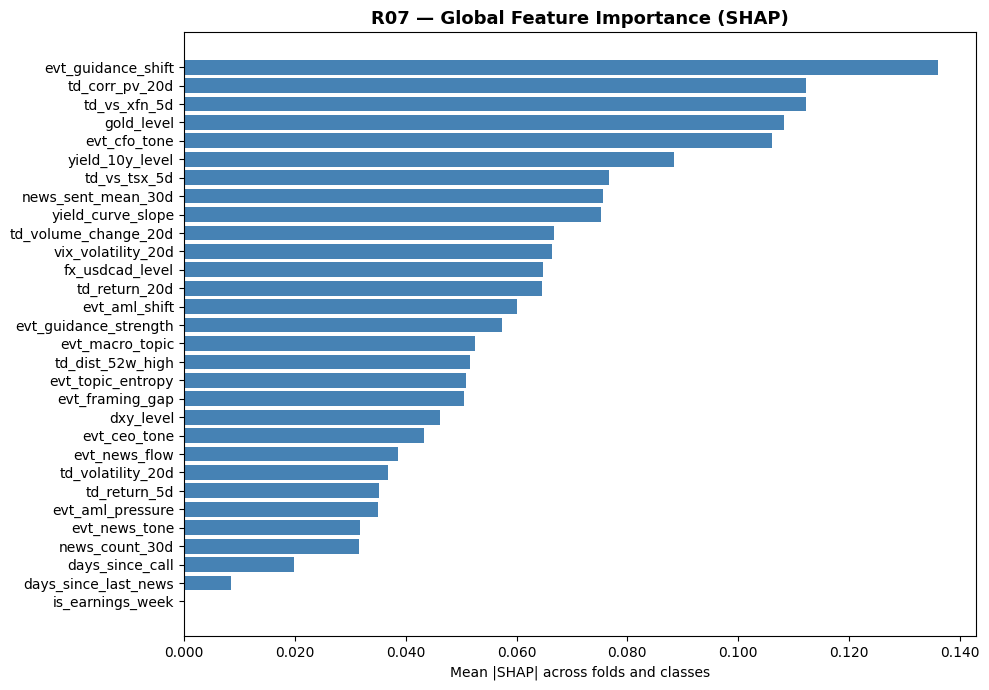


Top-10 features by mean |SHAP|:
evt_guidance_shift      0.136126
td_corr_pv_20d          0.112294
td_vs_xfn_5d            0.112250
gold_level              0.108314
evt_cfo_tone            0.106090
yield_10y_level         0.088419
td_vs_tsx_5d            0.076676
news_sent_mean_30d      0.075625
yield_curve_slope       0.075207
td_volume_change_20d    0.066696


In [6]:
shap_df   = pd.DataFrame(fold_shap_dfs)           # (7 folds, 30 features)
global_imp = shap_df.mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(global_imp.index[::-1], global_imp.values[::-1], color='steelblue')
ax.set_xlabel('Mean |SHAP| across folds and classes')
ax.set_title('R07 — Global Feature Importance (SHAP)', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
plt.tight_layout()
plt.show()

print('\nTop-10 features by mean |SHAP|:')
print(global_imp.head(10).to_string())

## 6. SHAP Stability Across Folds (Heatmap)

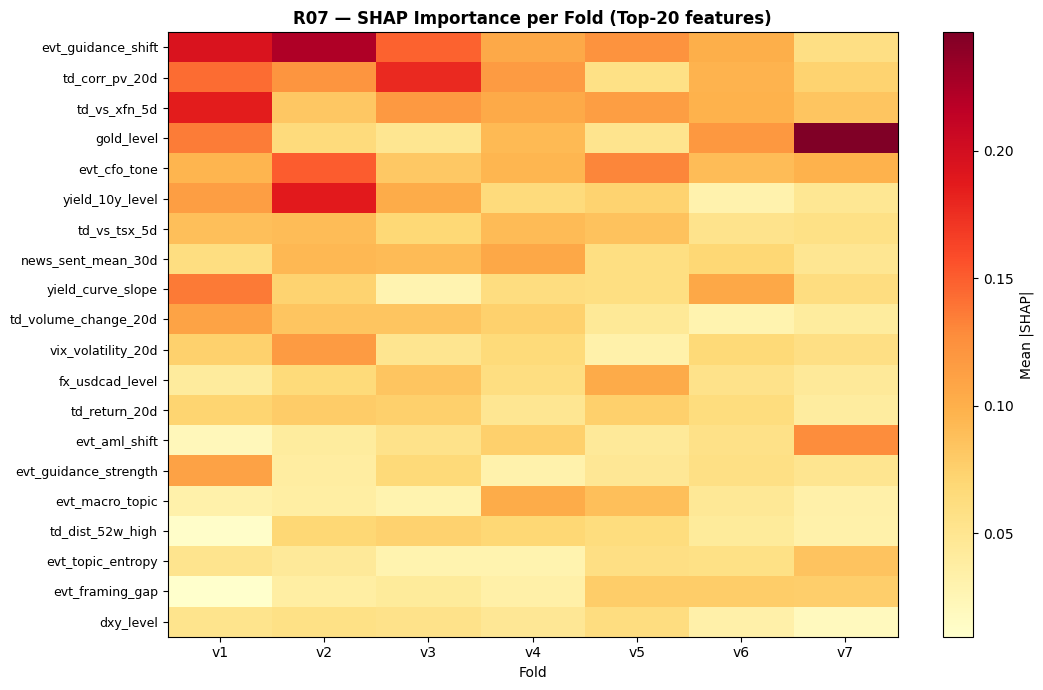

In [7]:
# Rank features by global mean, show top 20
top20 = global_imp.head(20).index.tolist()
heat  = shap_df[top20].T   # (features, folds)

fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(heat.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels([f'v{i+1}' for i in range(len(heat.columns))], fontsize=10)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20, fontsize=9)
ax.set_xlabel('Fold')
ax.set_title('R07 — SHAP Importance per Fold (Top-20 features)', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, label='Mean |SHAP|')
plt.tight_layout()
plt.show()

## 7. SHAP Beeswarm on Final Model (trained on all data)

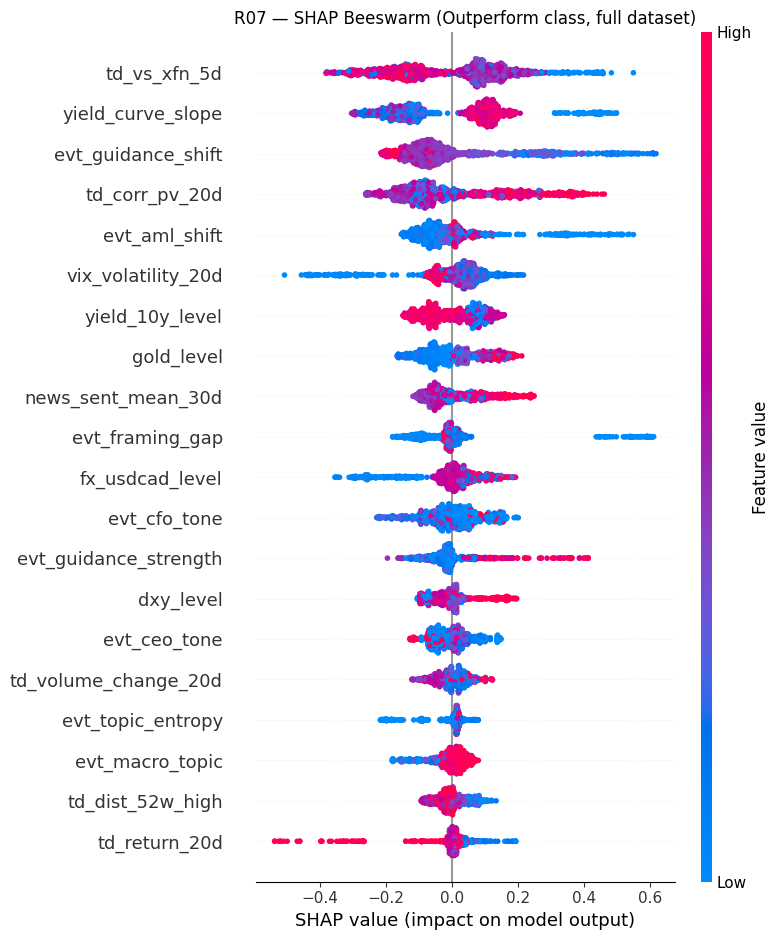

In [8]:
# Use the locked final model (trained on full dataset) for beeswarm
df_clean = df.dropna(subset=[TARGET])
x_all = df_clean[features].fillna(df_clean[features].median())

explainer_final = shap.TreeExplainer(model)
shap_vals_final = explainer_final.shap_values(x_all)

# Extract outperform class (label +1, encoded as index 2)
# Handle both old API (list per class) and new API (3D array)
if isinstance(shap_vals_final, list):
    sv_outperform = shap_vals_final[2]
else:
    sv = np.array(shap_vals_final)
    sv_outperform = sv[:, :, 2] if sv.ndim == 3 and sv.shape[-1] == 3 else sv[2]

shap.summary_plot(
    sv_outperform, x_all,
    feature_names=features,
    plot_type='dot',
    max_display=20,
    show=False,
)
plt.title('R07 — SHAP Beeswarm (Outperform class, full dataset)', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Feature List (Audit)

All 30 R07 features grouped by block for reproducibility.

In [9]:
feature_groups = {
    'Market / Price': ['td_return_5d', 'td_return_20d', 'td_volatility_20d',
                       'td_vs_xfn_5d', 'td_vs_tsx_5d', 'td_corr_pv_20d',
                       'td_volume_change_20d', 'td_dist_52w_high'],
    'Rates / Macro':  ['yield_curve_slope', 'yield_10y_level'],
    'Global Risk':    ['vix_volatility_20d', 'dxy_level', 'gold_level', 'fx_usdcad_level'],
    'News Flow':      ['news_sent_mean_30d', 'news_count_30d', 'days_since_last_news'],
    'Timing':         ['days_since_call', 'is_earnings_week'],
    'NLP Event':      ['evt_ceo_tone', 'evt_cfo_tone', 'evt_framing_gap',
                       'evt_aml_pressure', 'evt_aml_shift', 'evt_guidance_strength',
                       'evt_guidance_shift', 'evt_macro_topic', 'evt_topic_entropy',
                       'evt_news_tone', 'evt_news_flow'],
}

all_listed = sum(feature_groups.values(), [])
assert sorted(all_listed) == sorted(features), 'Feature group mismatch!'

for group, feats in feature_groups.items():
    print(f'\n{group} ({len(feats)} features):')
    for f in feats:
        print(f'  - {f}')

print(f'\nTotal: {len(features)} features ✓')


Market / Price (8 features):
  - td_return_5d
  - td_return_20d
  - td_volatility_20d
  - td_vs_xfn_5d
  - td_vs_tsx_5d
  - td_corr_pv_20d
  - td_volume_change_20d
  - td_dist_52w_high

Rates / Macro (2 features):
  - yield_curve_slope
  - yield_10y_level

Global Risk (4 features):
  - vix_volatility_20d
  - dxy_level
  - gold_level
  - fx_usdcad_level

News Flow (3 features):
  - news_sent_mean_30d
  - news_count_30d
  - days_since_last_news

Timing (2 features):
  - days_since_call
  - is_earnings_week

NLP Event (11 features):
  - evt_ceo_tone
  - evt_cfo_tone
  - evt_framing_gap
  - evt_aml_pressure
  - evt_aml_shift
  - evt_guidance_strength
  - evt_guidance_shift
  - evt_macro_topic
  - evt_topic_entropy
  - evt_news_tone
  - evt_news_flow

Total: 30 features ✓
